# 1. Implementa el generador de números aleatorios (PRNG) propuesto por Wichmann & Hill en 1982, el cual se define como:

# $$X_{n+1} = 171 \cdot X_n (\bmod 30269)$$
# $$Y_{n+1} = 172 \cdot Y_n (\bmod 30307)$$
# $$Z_{n+1} = 170 \cdot Z_n (\bmod 30323).$$
# y así, definimos un valor en el intervalo unitario como:

# $$U_{n+1} = (\frac{X_{n+1}}{30269} + \frac{Y_{n+1}}{30307} + \frac{Z_{n+1}}{30323}) (\bmod 1).$$

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
sns.set_theme(style = 'whitegrid', palette="GnBu_r")

In [31]:
def prng(n, seed = [29, 30, 31]):
  U = []
  X = seed[0]
  Y = seed[1]
  Z = seed[2]
  for i in range(n):
    X = (171 * X) % 30269
    Y = (172 * Y) % 30307
    Z = (170 * Z) % 30323
    U.append((X/30269 + Y/30307 + Z/30323) % 1)
  return U

## (a) Elige semillas iniciales $X_0, Y_0$ y $Z_0$ mayores a cero y menores a $30269, 30307$ y $30323$ respectivamente y genera una muestra de tamaño $10,000$.

In [32]:
muestra = prng(10000, seed = [29, 30, 31])

## (b) Con base en las herramientas gráficas y pruebas estadísticas estudiadas en el curso, evalúa si existe evidencia de desviaciones importantes de uniformidad o independencia en la secuencia generada.

### Q-Q Plot

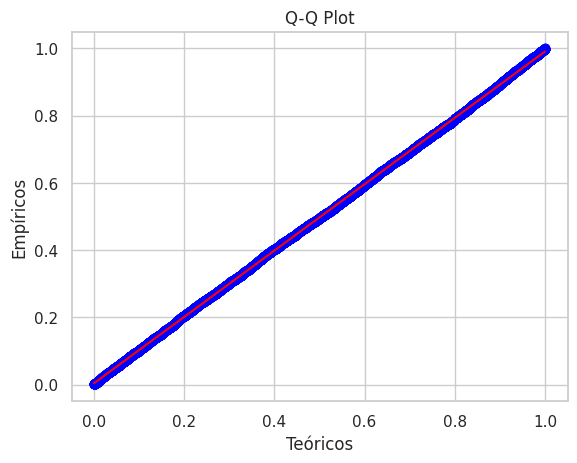

In [33]:
fig, ax = plt.subplots()
stats.probplot(muestra, dist = 'uniform', plot = ax)

ax.set_xlabel("Teóricos")
ax.set_ylabel("Empíricos")
ax.set_title("Q-Q Plot")
plt.show()

Con el Q-Q Plot pareciera que si siguen una distribucion Uniforme

### Histograma

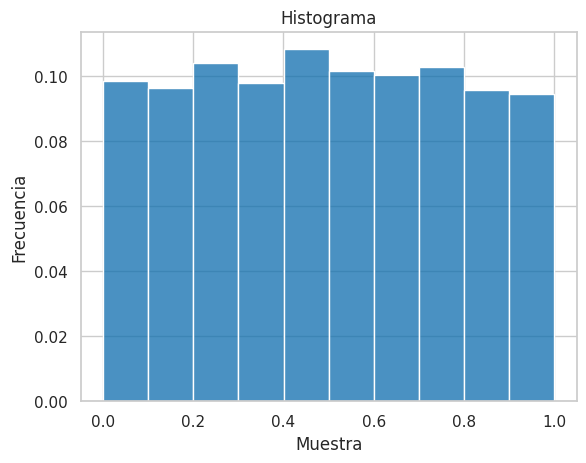

In [34]:
fig, ax = plt.subplots()
sns.histplot(muestra, stat = 'probability', bins = 10, ax = ax)

ax.set_xlabel("Muestra")
ax.set_ylabel("Frecuencia")
ax.set_title("Histograma")
plt.show()

El hisograma pareciera converger a una uniforme

### K-S y Rachas

In [35]:
from statsmodels.sandbox.stats.runs import runstest_1samp

In [36]:
muestra = np.array(muestra).ravel()
N = len(muestra)
h = int(np.floor(N / 4))

p_val_ks = stats.kstest(muestra, 'uniform').pvalue
p_val_runs = runstest_1samp((muestra > 0.5).astype(int), cutoff=0.5)[1]

print(f"p-valor KS: {p_val_ks:.4f} | p-valor Runs: {p_val_runs:.4f}")

p-valor KS: 0.0792 | p-valor Runs: 0.9914


Por los p values, podemos ver que tanto la distribucion parece ser Uniforme  y además las variables si parecen ser independientes.

### Autocorrelación

In [37]:
from statsmodels.graphics.tsaplots import plot_acf

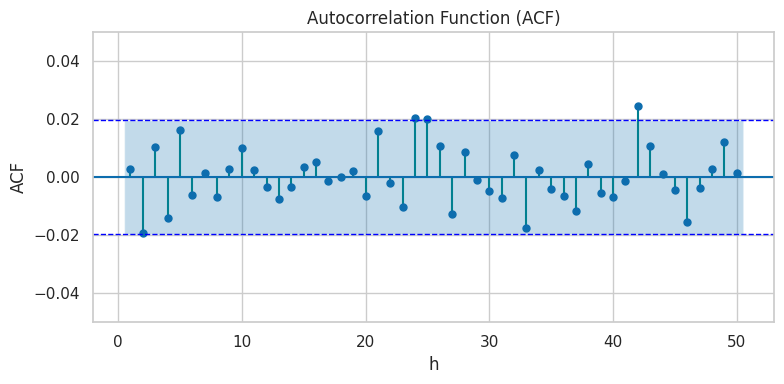

In [38]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_acf(
    muestra,
    lags=50,
    zero=False,
    ax=ax,
    title="Autocorrelation Function (ACF)",
    vlines_kwargs={"colors": "#028090", "linewidth": 1.5},
    markersize=5
)

limite = 1.96 / np.sqrt(N)
ax.axhline(y=limite, color='blue', linestyle='--', linewidth=1)
ax.axhline(y=-limite, color='blue', linestyle='--', linewidth=1)

ax.set_xlabel("h")
ax.set_ylabel("ACF")

plt.ylim(-0.05, 0.05)
plt.tight_layout()
plt.show()

No hay autocorrelacion significativa

### Ljung-Box

In [39]:
from statsmodels.stats.diagnostic import acorr_ljungbox

resultados_lb = acorr_ljungbox(muestra, lags=[10], return_df=True)
print(resultados_lb)

      lb_stat  lb_pvalue
10  11.509205   0.319245


Tampoco hay correlacion significativa

### Lags

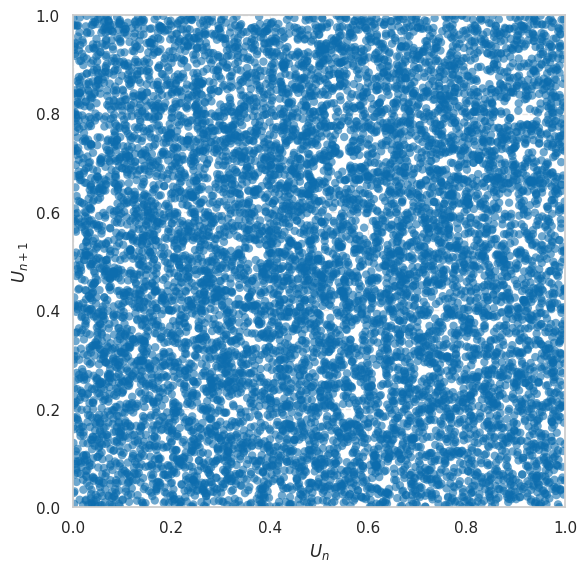

In [40]:
lag_pairs = pd.DataFrame({
    'U_n': muestra[:-1],
    'U_n1': muestra[1:]
})

# 3. Crear el gráfico de dispersión
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(
    lag_pairs['U_n'],
    lag_pairs['U_n1'],
    alpha=0.6,
    edgecolors='none'
)

# Configurar escala 1:1 y límites estrictos de 0 a 1
ax.set_aspect('equal')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Etiquetas de los ejes
ax.set_xlabel(r'$U_n$')
ax.set_ylabel(r'$U_{n+1}$')

# Cuadrícula equivalente a theme_minimal
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_facecolor('white')

plt.tight_layout()
plt.show()

Los lags no muestran correlacion

# 2. Considera la distribución Cauchy estándar cuya densidad está dada por
$$f(x) = \frac{1}{π(1 + x^2)}.$$

## (a) Encuentra la función de distribución y su inversa.

La funcion de distribucion será
$$F(t) = \int_{-\infty}^{t} \frac{dx}{π(1 + x^2)}  = \frac{1}{\pi}\int_{-\infty}^{t} \frac{dx}{(1 + x^2)} = \frac{1}{\pi}\tan^{-1}(x)|_{-\infty}^{t} = \frac{1}{\pi}\tan^{-1}(t) -\frac{1}{2}$$
será la funcion de distribución. Ahora calculemos la inversa, si $y = \frac{1}{\pi}\tan^{-1}(t) -\frac{1}{2}$, entonces:
$$ y- \frac{1}{2} = \frac{1}{\pi} \tan^{-1}(t) ⇒ \pi(y-\frac{1}{2}) = tan^{-1}(t) ⇒ t = \tan(\pi(y -\frac{1}{2})).$$

Con lo cual, $F^{-1}(t) = \tan(\pi(y -\frac{1}{2}))$.

## (b) Diseña un algoritmo para simular variables aleatorias Cauchy estándar e impleméntalo.

Por la propocision vista en clase, sabemos que $F^{-1}(U) \sim \mathcal{C}(0, 1)$ con, $U \sim \mathcal{U}(0, 1)$.

In [41]:
def cauchy(n, seed = 30):
  np.random.seed(seed)
  U = np.random.uniform(0, 1, n)
  return np.tan(np.pi * (U - 0.5))

In [42]:
cauchy(10)

array([ 0.48656292, -0.39321047,  0.56229024, -1.77058375,  8.47354494,
       -0.52280667, 38.57901903, -1.09858417,  0.27591479, -0.30183747])

## (c) Genera $100$ muestras de tamaños $100$, $1,000$, $10,000$ y $100,000$ y analiza el comportamiento de $\bar{X}$. Explica el comportamiento observado a partir de las propiedades de la distribución Cauchy.

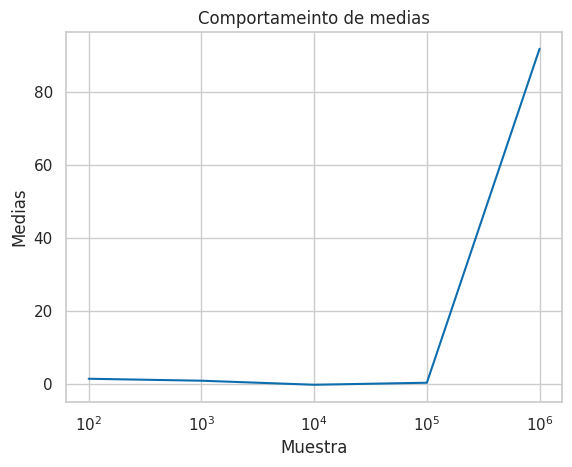

In [43]:
X = [100, 1000, 10000, 100000, 1000000]
Xbar =[]
for i in X:
  muestra = cauchy(i)
  Xbar.append(sum(muestra)/i)

fig, ax = plt.subplots()
ax.plot(X, Xbar)
ax.set_xlabel("Muestra")
ax.set_ylabel("Medias")
ax.set_title("Comportameinto de medias")
ax.set_xscale("log")
plt.show()

Vemos que las medias no convergen, esto ya que la distribución Cauchy no tiene media, ya que $\mathbb{E}[X_n] → \infty$ cuando $n → \infty$ con $X_n \sim \mathcal{Cauchy}(0,1)$. Por lo cual no ocurre la Ley de Los Grandes Números.

# 3. Supongamos que se desea simular de una variable aleatoria Poisson de parámetro $λ$.

## (a) Diseña e implementa un algoritmo utilizando la función inversa generalizada y evaluando de forma exacta la función de masa, esto es, $\mathbb{P}(X = k) = \frac{λ^k\exp(−λ)}{k!}$.

In [44]:
import math

def poisson_inv(n, lam, seed = 31):
  np.random.seed(seed)
  U = np.random.uniform(0, 1, n)
  X = np.zeros(n)
  for i in range(n):
    k = 0
    F = np.exp(-lam)
    while U[i] >= F:
      k += 1
      F += (np.exp(-lam)*(lam ** k))/math.factorial(k)
    X[i] = k
  return X

In [45]:
poisson_inv(1000, 6)

array([ 5., 11.,  8., 12.,  4.,  3.,  9.,  3.,  3.,  6.,  3.,  5.,  7.,
        5.,  2.,  4.,  6.,  3.,  5., 10.,  4.,  4.,  5.,  8.,  6.,  4.,
        5., 11.,  4.,  4.,  7.,  5.,  6.,  7.,  3.,  4.,  6.,  3.,  3.,
        3.,  5.,  9.,  8.,  8.,  6.,  9.,  4.,  3.,  3.,  6.,  5.,  5.,
        1.,  6.,  7.,  5.,  4.,  4.,  8.,  5.,  5.,  8.,  9.,  8.,  5.,
        5.,  6.,  6.,  9.,  8.,  3.,  5.,  5.,  7.,  7.,  6.,  5.,  2.,
        2.,  8.,  4.,  5.,  8.,  5.,  6.,  1.,  5.,  6.,  5.,  7.,  4.,
        4.,  5.,  7.,  5.,  6.,  8.,  7.,  9.,  8.,  5., 12.,  9.,  6.,
        6.,  6.,  5.,  3.,  5.,  2.,  5.,  4.,  8.,  9.,  9., 11.,  6.,
        6., 12.,  5.,  6.,  4.,  5.,  6.,  5., 11., 12.,  3.,  4.,  6.,
        2.,  4.,  4.,  8.,  2.,  7.,  6.,  6.,  5.,  8.,  9.,  4.,  7.,
        4.,  8.,  4.,  8., 11.,  0.,  3., 12.,  4.,  5.,  6.,  6.,  3.,
        7.,  3., 10.,  2.,  3.,  8.,  6., 10.,  8.,  4.,  9.,  5.,  4.,
        4., 10.,  3.,  6.,  2.,  6.,  5.,  3.,  4.,  4.,  2.,  6

## (b) Genera una segunda versión del algoritmo utilizando la propiedad recursiva de la función masa.

In [46]:
def poisson_rec(n, lam, seed = 31):
  np.random.seed(seed)
  U = np.random.uniform(0, 1, n)
  X = np.zeros(n)
  for i in range(n):
    k = 0
    p = np.exp(-lam)
    F = p
    while U[i] >= F:
      k += 1
      p = p * lam / k
      F += p
    X[i] = k
  return X

In [47]:
poisson_rec(5, 6)

array([ 5., 11.,  8., 12.,  4.])

In [48]:
poisson_rec(1000, 1)

array([0., 3., 2., 4., 0., 0., 2., 0., 0., 1., 0., 1., 1., 1., 0., 0., 1.,
       0., 0., 3., 0., 0., 1., 2., 1., 0., 0., 3., 0., 0., 1., 1., 1., 1.,
       0., 0., 1., 0., 0., 0., 0., 2., 2., 2., 1., 2., 0., 0., 0., 1., 0.,
       0., 0., 1., 1., 1., 0., 0., 2., 0., 1., 2., 2., 2., 1., 1., 1., 1.,
       2., 2., 0., 0., 1., 1., 1., 1., 0., 0., 0., 2., 0., 1., 2., 1., 1.,
       0., 1., 1., 0., 1., 0., 0., 1., 1., 0., 1., 2., 1., 2., 2., 0., 4.,
       2., 1., 1., 1., 0., 0., 0., 0., 0., 0., 2., 2., 2., 3., 1., 1., 4.,
       0., 1., 0., 1., 1., 0., 3., 3., 0., 0., 1., 0., 0., 0., 2., 0., 1.,
       1., 1., 1., 2., 2., 0., 1., 0., 2., 0., 2., 3., 0., 0., 4., 0., 0.,
       1., 1., 0., 1., 0., 3., 0., 0., 2., 1., 3., 2., 0., 2., 1., 0., 0.,
       3., 0., 1., 0., 1., 0., 0., 0., 0., 0., 1., 0., 3., 1., 2., 0., 0.,
       2., 0., 1., 1., 0., 0., 0., 0., 2., 2., 1., 1., 0., 1., 0., 0., 3.,
       1., 1., 0., 1., 3., 1., 0., 0., 0., 1., 1., 3., 3., 1., 2., 2., 1.,
       2., 0., 0., 3., 0.

## (c) Diseña e implementa el algoritmo a partir del proceso Poisson visto en clase.

In [49]:
def poisson(n, lam, seed = 31):
  np.random.seed(seed)
  U = np.random.uniform(0, 1, n*lam)
  X = np.zeros(n)
  m = 0
  for i in range(n):
    k = 0
    suma = 0
    while suma < 1:
      if m >= len(U):
        U = np.random.uniform(0, 1, (n-i)*lam)
        m = 0
      suma += -np.log(U[m])/lam
      m += 1
      k += 1
    X[i] = k - 1
  return X

In [50]:
poisson(1000, 5)

array([ 5.,  2.,  4.,  2.,  3.,  5.,  5.,  4.,  2.,  6.,  4.,  4.,  8.,
        5.,  4.,  2.,  4.,  5.,  8.,  6.,  2.,  9.,  6.,  2.,  3.,  8.,
        4.,  5.,  2.,  2.,  7.,  4.,  3.,  2.,  5.,  5.,  1.,  6.,  8.,
        2.,  9.,  4.,  6.,  4.,  4.,  5.,  6.,  7.,  4.,  3.,  5.,  6.,
        6.,  5.,  5.,  1.,  7.,  7.,  9.,  5.,  3.,  1., 10.,  5.,  7.,
        3.,  7.,  3.,  3.,  7.,  6.,  1.,  3.,  9.,  5.,  5.,  6.,  3.,
        5.,  8.,  2.,  4.,  2.,  5.,  4.,  5.,  5.,  8.,  6.,  4.,  2.,
        4., 11.,  4.,  5., 10.,  4.,  5., 10.,  5.,  4.,  4.,  4.,  6.,
        5.,  9., 10.,  7.,  4.,  7.,  5.,  3.,  6.,  1., 10.,  6.,  4.,
        5.,  6.,  3.,  3.,  5.,  5.,  5.,  5.,  6.,  7.,  3., 10.,  5.,
        6.,  3.,  7.,  2.,  7.,  8.,  3.,  5.,  5.,  5.,  1.,  4.,  5.,
        4.,  7.,  9.,  6.,  4.,  9.,  3.,  4.,  7.,  3.,  4.,  5.,  5.,
        4.,  4.,  7.,  5.,  3.,  9.,  5.,  6.,  5.,  4.,  5.,  6.,  4.,
        4.,  4.,  3.,  7.,  2.,  5.,  5.,  6.,  5.,  2., 12.,  5

## (d) Verifica mediante herramientas gráficas y estadísticas apropiadas que los algoritmos producen muestras compatibles con una distribución $\mathcal{Poisson}(λ)$.

### Q-Q Plot

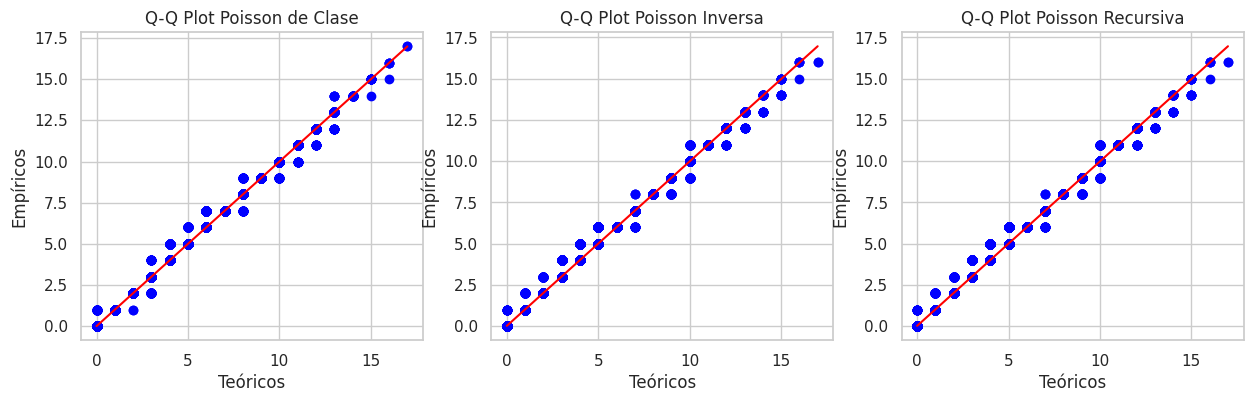

In [51]:
muestra_inv = poisson_inv(100000, 5)
muestra_rec = poisson_rec(100000, 5)
muestra_cla = poisson(100000, 5)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
stats.probplot(muestra_cla, dist = stats.poisson, sparams = (5,), plot = ax1)
stats.probplot(muestra_inv, dist = stats.poisson, sparams = (5,), plot = ax2)
stats.probplot(muestra_rec, dist = stats.poisson, sparams = (5,), plot = ax3)

ax1.set_xlabel("Teóricos")
ax1.set_ylabel("Empíricos")
ax1.set_title("Q-Q Plot Poisson de Clase")

ax2.set_xlabel("Teóricos")
ax2.set_ylabel("Empíricos")
ax2.set_title("Q-Q Plot Poisson Inversa")

ax3.set_xlabel("Teóricos")
ax3.set_ylabel("Empíricos")
ax3.set_title("Q-Q Plot Poisson Recursiva")
plt.show()

Los 3 plots muestran que la distribucion es Poisson

### Histograma

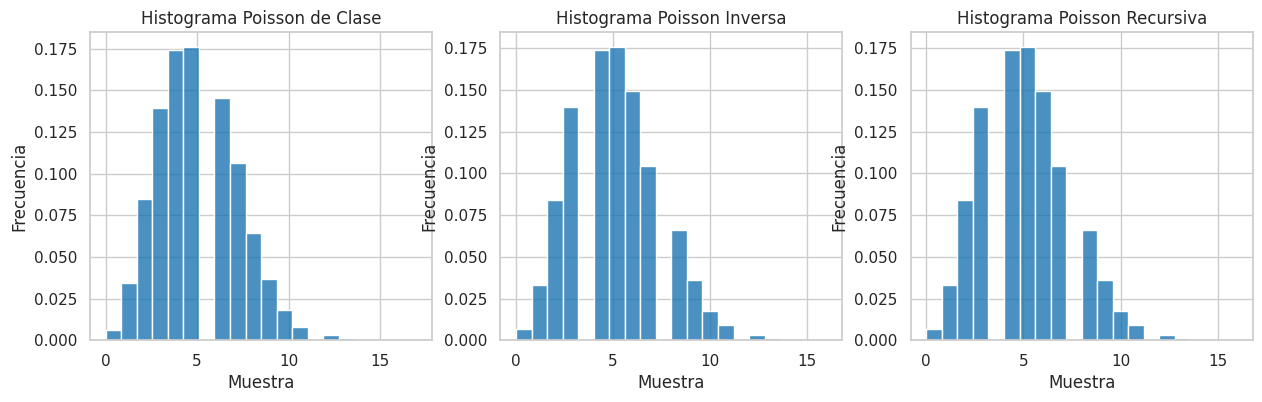

In [52]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(muestra_cla, stat = 'probability', bins = 20, ax = ax1)
sns.histplot(muestra_inv, stat = 'probability', bins = 20, ax = ax2)
sns.histplot(muestra_rec, stat = 'probability', bins = 20, ax = ax3)

ax1.set_xlabel("Muestra")
ax1.set_ylabel("Frecuencia")
ax1.set_title("Histograma Poisson de Clase")

ax2.set_xlabel("Muestra")
ax2.set_ylabel("Frecuencia")
ax2.set_title("Histograma Poisson Inversa")

ax3.set_xlabel("Muestra")
ax3.set_ylabel("Frecuencia")
ax3.set_title("Histograma Poisson Recursiva")
plt.show()

Los histogramas tambien se comportan como una Poisson

## (e) Compara el tiempo de ejecución de los tres algoritmos para generar muestras de tamaños $n = 100$, $1,000$, $10,000$, $100,000$ y para $λ = 1, 10, 50$. ¿Cuál resulta más eficiente en cada caso? Discute los resultados considerando tanto el tiempo de cómputo como las operaciones requeridas por cada algoritmo.

In [53]:
import time

X = [100, 1000, 10000, 100000, 1000000]
lams = [1, 10, 50]
tiempos = []

for i in X:
    for j in lams:
        t0 = time.perf_counter()
        poisson_inv(i, j)
        t_inv = (time.perf_counter() - t0) * 1000
        t0 = time.perf_counter()
        poisson_rec(i, j)
        t_rec = (time.perf_counter() - t0) * 1000
        t0 = time.perf_counter()
        poisson(i, j)
        t_cla = (time.perf_counter() - t0) * 1000

        tiempos.append({
            'n': i,
            'lambda': j,
            'Inversa (ms)': round(t_inv, 3),
            'Recursiva (ms)': round(t_rec, 3),
            }+
            'Clase (ms)': round(t_cla, 3)
        })

tiempos = pd.DataFrame(tiempos)
tiempos

cols = ['Inversa (ms)', 'Recursiva (ms)', 'Clase (ms)']
tiempos['Mas_Rapido'] = tiempos[cols].idxmin(axis=1)

In [54]:
tiempos

,n,lambda,Inversa (ms),Recursiva (ms),Clase (ms),Mas_Rapido
0,100,1,0.587,0.305,0.550,Recursiva (ms)
1,100,10,2.326,0.742,2.131,Recursiva (ms)
2,100,50,15.561,2.657,10.440,Recursiva (ms)
3,1000,1,4.271,2.624,3.919,Recursiva (ms)
4,1000,10,27.218,6.376,17.840,Recursiva (ms)
5,1000,50,149.563,22.992,88.626,Recursiva (ms)
6,10000,1,47.857,31.091,42.865,Recursiva (ms)
7,10000,10,267.989,60.211,177.675,Recursiva (ms)
8,10000,50,1505.511,230.557,853.849,Recursiva (ms)
9,100000,1,455.721,250.975,350.327,Recursiva (ms)


La funcion mas eficiente parece ser en la que utilizamos la propiedad recursiva de la distribución Poisson. Esto tiene sentido considerando que en cada paso unicamente realizamos una mutliplicación y una division, mientras que en el ejemplo visto en la clase se utilizan varias sumas y logaritmos naturales, dependiendo del valor de $\lambda$. Además podemos ver que mientras aumenta el valor de $\lambda$, tambien aumenta la diferencia con el tiempo que toma con la funcion ralizada a partir de la propiedad recursiva.

Así mismo la funcion realizada unicamente con la funcion inversa es muy costosa computacionalmente ya que se necesita realizar diversas multiplicaciones con el factoríal.